# Thai Receipt Orientation Classification
## Fast Training — ResNet-18 Transfer Learning

This notebook adapts the training pipeline from `Thai_Receipt_Local_PC_Training_EfficientNetV2M.ipynb` to use a lightweight **ResNet-18** backbone (224x224 resolution). This substantially accelerates training while adhering to all project requirements:
- Split original receipts into train and validation sets **before** creating rotation classes.
- Dynamically generate 4 classes (`0°`, `90°`, `180°`, `270°`).
- Apply **orientation-safe** data augmentations (no flips or arbitrary rotations).
- Two-stage transfer learning (Freeze backbone -> Fine-tune top layers).
- Evaluation with Confusion Matrix and portable `.pth` checkpoint export.

In [2]:
from pathlib import Path
import copy
import random
import re
import sys
import time

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageOps

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
from torchvision.models import resnet18, ResNet18_Weights
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# Device setup: Apple Silicon (MPS) -> CUDA -> CPU
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Python:  {sys.version.split()[0]}")
print(f"PyTorch: {torch.__version__}")
print(f"Device:  {device}")

Python:  3.12.7
PyTorch: 2.5.1
Device:  mps


## 1. Configuration
Configure paths, hyper-parameters, and rotation rules here.

In [3]:
SEED = 42
VAL_FRACTION = 0.20

# ResNet-18 uses standard 224x224 input resolution
IMAGE_SIZE = 224
BATCH_SIZE = 16

# Two-stage learning parameters
STAGE1_EPOCHS = 5        # Train classifier head only
STAGE2_EPOCHS = 15         # Fine-tune backbone
STAGE1_LEARNING_RATE = 1e-3
STAGE2_LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 0            # Set to 0 to prevent spawn crashes on Windows/macOS

ROTATION_CONVENTION = 'clockwise'   # 'clockwise' or 'counterclockwise'
CLASS_NAMES = ['0', '90', '180', '270']
CLASS_ANGLES = [0, 90, 180, 270]

# Path configuration (adjust to your Google Drive or local path if needed)
PROJECT_ROOT = Path('/Users/sam/ai_concepts/project')
ORIGINAL_DIR = PROJECT_ROOT / 'raw_originals'
OUTPUT_DIR = PROJECT_ROOT / 'receipt_project_outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_SAVE_PATH = OUTPUT_DIR / 'thai_receipt_orientation_resnet18.pth'

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()
print(f"Project root:   {PROJECT_ROOT}")
print(f"Originals dir:  {ORIGINAL_DIR}")
print(f"Output save dir:{OUTPUT_DIR}")

Project root:   /Users/sam/ai_concepts/project
Originals dir:  /Users/sam/ai_concepts/project/raw_originals
Output save dir:/Users/sam/ai_concepts/project/receipt_project_outputs


## 2. Dataset Verification & Train/Val Split
Images in `receipts_original` must be upright (0°). We split the unique original files into train/validation sets **prior** to any rotation.

In [4]:
IMG_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

def natural_key(path):
    parts = re.split(r'(\d+)', path.name.lower())
    return [int(x) if x.isdigit() else x for x in parts]

assert ORIGINAL_DIR.exists(), f"Folder '{ORIGINAL_DIR}' not found. Please place upright receipts inside."

original_files = sorted(
    [p for p in ORIGINAL_DIR.iterdir() if p.is_file() and p.suffix.lower() in IMG_EXTENSIONS],
    key=natural_key
)

num_originals = len(original_files)
print(f"Found {num_originals} unique original receipts.")
assert num_originals >= 200, f"Project requirement expects at least 200 originals (found {num_originals})."

# Split original documents before generating rotation classes
train_files, val_files = train_test_split(
    original_files, test_size=VAL_FRACTION, random_state=SEED, shuffle=True
)

print(f"Training original receipts:   {len(train_files)} (will produce {len(train_files) * 4} samples)")
print(f"Validation original receipts: {len(val_files)} (will produce {len(val_files) * 4} samples)")

Found 218 unique original receipts.
Training original receipts:   174 (will produce 696 samples)
Validation original receipts: 44 (will produce 176 samples)


## 3. Safe Augmentations & Dataset Class
**Crucial Rule:** We use color jitter, slight affine translation, and scaling. We **never** use horizontal/vertical flipping or random arbitrary rotation because they destroy the receipt's upright orientation label.

In [5]:
# Orientation-safe transforms
train_transforms = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.15),
    T.RandomAffine(degrees=0, translate=(0.04, 0.04), scale=(0.95, 1.05)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

val_transforms = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

class ReceiptOrientationDataset(Dataset):
    """
    Generates 4 discrete orientation classes (0, 90, 180, 270) for each original receipt.
    """
    def __init__(self, file_list, convention='clockwise', transform=None):
        self.transform = transform
        self.convention = convention
        self.samples = []
        
        # For every original receipt, register all 4 orientations
        for path in file_list:
            for class_idx, angle in enumerate(CLASS_ANGLES):
                self.samples.append((path, class_idx, angle))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label, angle = self.samples[idx]
        
        with Image.open(img_path) as img:
            img = img.convert('RGB')
            # Normalize phone camera EXIF tags so 0 degrees is truly upright
            img = ImageOps.exif_transpose(img)
            
            # PIL rotates counter-clockwise by default; negate angle for clockwise
            rot_angle = -angle if self.convention == 'clockwise' else angle
            if angle != 0:
                img = img.rotate(rot_angle, expand=True)
                
            if self.transform is not None:
                tensor_img = self.transform(img)
            else:
                tensor_img = T.ToTensor()(img)
                
        return tensor_img, label

train_dataset = ReceiptOrientationDataset(train_files, convention=ROTATION_CONVENTION, transform=train_transforms)
val_dataset = ReceiptOrientationDataset(val_files, convention=ROTATION_CONVENTION, transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f"Total training samples:   {len(train_dataset)}")
print(f"Total validation samples: {len(val_dataset)}")

Total training samples:   696
Total validation samples: 176


### Visual Verification of 4-Class Rotations

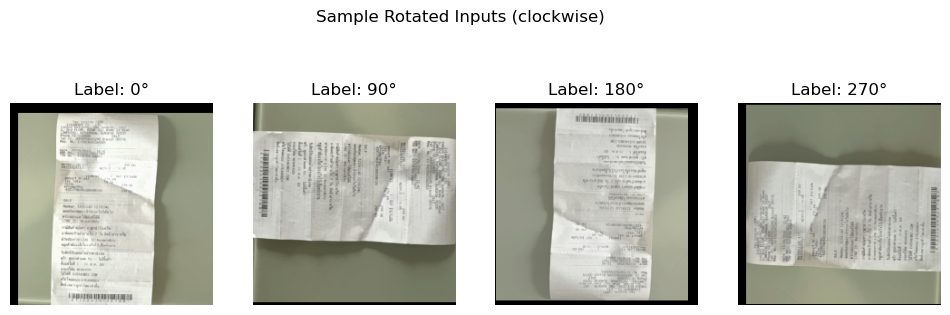

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(12, 4))
for i in range(4):
    img_t, lbl = train_dataset[i]
    # Denormalize for plotting
    np_img = img_t.numpy().transpose(1, 2, 0)
    np_img = np_img * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
    np_img = np.clip(np_img, 0, 1)
    
    axes[i].imshow(np_img)
    axes[i].set_title(f"Label: {CLASS_NAMES[lbl]}°")
    axes[i].axis('off')
plt.suptitle(f"Sample Rotated Inputs ({ROTATION_CONVENTION})")
plt.show()

## 4. ResNet-18 Model Setup & Two-Stage Training
We load pretrained ResNet-18 weights, substitute the final fully connected layer for 4 classes, and train in two stages.

In [7]:
def create_model(num_classes=4):
    model = resnet18(weights=ResNet18_Weights.DEFAULT)
    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, num_classes)
    return model.to(device)

model = create_model(len(CLASS_NAMES))
criterion = nn.CrossEntropyLoss()

def train_loop(model, dataloader, optimizer, criterion):
    model.train()
    running_loss, running_correct = 0.0, 0
    total = 0
    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        preds = outputs.argmax(dim=1)
        running_loss += loss.item() * inputs.size(0)
        running_correct += (preds == labels).sum().item()
        total += inputs.size(0)
    return running_loss / total, running_correct / total

@torch.no_grad()
def eval_loop(model, dataloader, criterion):
    model.eval()
    running_loss, running_correct = 0.0, 0
    total = 0
    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        preds = outputs.argmax(dim=1)
        running_loss += loss.item() * inputs.size(0)
        running_correct += (preds == labels).sum().item()
        total += inputs.size(0)
    return running_loss / total, running_correct / total

best_weights = copy.deepcopy(model.state_dict())
best_val_acc = 0.0
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

### Stage 1: Train Classifier Head Only
Backbone layers are frozen so only the new output weights adjust.

In [8]:
print("--- Stage 1: Training Classifier Head ---")
for name, param in model.named_parameters():
    if 'fc' not in name:
        param.requires_grad = False
    else:
        param.requires_grad = True

optimizer_stage1 = optim.Adam(model.fc.parameters(), lr=STAGE1_LEARNING_RATE, weight_decay=WEIGHT_DECAY)

for epoch in range(STAGE1_EPOCHS):
    tr_loss, tr_acc = train_loop(model, train_loader, optimizer_stage1, criterion)
    val_loss, val_acc = eval_loop(model, val_loader, criterion)
    
    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_weights = copy.deepcopy(model.state_dict())
        
    print(f"Stage 1 | Epoch {epoch+1:02d}/{STAGE1_EPOCHS:02d} | Train Loss: {tr_loss:.4f} Acc: {tr_acc*100:.2f}% | Val Loss: {val_loss:.4f} Acc: {val_acc*100:.2f}%")

--- Stage 1: Training Classifier Head ---


KeyboardInterrupt: 

### Stage 2: Fine-Tuning
Unfreeze higher convolutional blocks (layer3, layer4, and fc) using a reduced learning rate.

In [ ]:
print("\n--- Stage 2: Fine-Tuning ResNet-18 Layers ---")
# Unfreeze layer3, layer4, and fc
for name, param in model.named_parameters():
    if any(k in name for k in ['layer3', 'layer4', 'fc']):
        param.requires_grad = True
    else:
        param.requires_grad = False

trainable_params = [p for p in model.parameters() if p.requires_grad]
optimizer_stage2 = optim.Adam(trainable_params, lr=STAGE2_LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer_stage2, T_max=STAGE2_EPOCHS)

for epoch in range(STAGE2_EPOCHS):
    tr_loss, tr_acc = train_loop(model, train_loader, optimizer_stage2, criterion)
    val_loss, val_acc = eval_loop(model, val_loader, criterion)
    scheduler.step()
    
    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_weights = copy.deepcopy(model.state_dict())
        
    print(f"Stage 2 | Epoch {epoch+1:02d}/{STAGE2_EPOCHS:02d} | Train Loss: {tr_loss:.4f} Acc: {tr_acc*100:.2f}% | Val Loss: {val_loss:.4f} Acc: {val_acc*100:.2f}%")

# Restore best model state
model.load_state_dict(best_weights)
print(f"\nTraining complete! Best Validation Accuracy: {best_val_acc*100:.2f}%")


--- Stage 2: Fine-Tuning ResNet-18 Layers ---
Stage 2 | Epoch 01/15 | Train Loss: 0.6642 Acc: 67.10% | Val Loss: 0.4335 Acc: 78.41%
Stage 2 | Epoch 02/15 | Train Loss: 0.2587 Acc: 92.24% | Val Loss: 0.2794 Acc: 88.64%
Stage 2 | Epoch 03/15 | Train Loss: 0.1146 Acc: 96.41% | Val Loss: 0.2297 Acc: 89.20%
Stage 2 | Epoch 04/15 | Train Loss: 0.1051 Acc: 96.41% | Val Loss: 0.2189 Acc: 91.48%
Stage 2 | Epoch 05/15 | Train Loss: 0.0874 Acc: 97.41% | Val Loss: 0.2497 Acc: 92.61%
Stage 2 | Epoch 06/15 | Train Loss: 0.0755 Acc: 97.70% | Val Loss: 0.2488 Acc: 92.61%
Stage 2 | Epoch 07/15 | Train Loss: 0.0739 Acc: 97.84% | Val Loss: 0.2065 Acc: 92.61%
Stage 2 | Epoch 08/15 | Train Loss: 0.0441 Acc: 98.99% | Val Loss: 0.1959 Acc: 94.32%
Stage 2 | Epoch 09/15 | Train Loss: 0.0362 Acc: 98.99% | Val Loss: 0.1840 Acc: 93.18%
Stage 2 | Epoch 10/15 | Train Loss: 0.0327 Acc: 99.14% | Val Loss: 0.1802 Acc: 93.18%
Stage 2 | Epoch 11/15 | Train Loss: 0.0205 Acc: 99.57% | Val Loss: 0.1444 Acc: 93.75%
Stage 2

## 5. Evaluation & Confusion Matrix

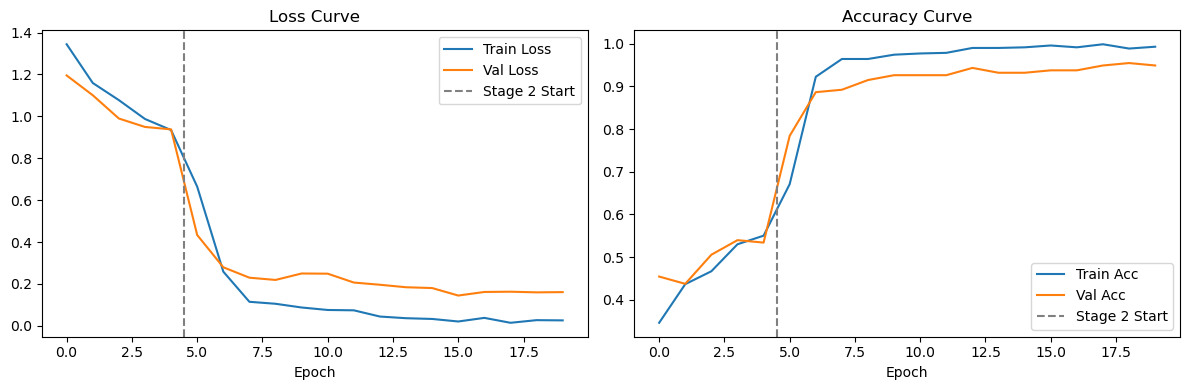


--- Classification Report ---
              precision    recall  f1-score   support

          0°       0.98      0.98      0.98        44
         90°       0.91      0.98      0.95        44
        180°       1.00      0.95      0.98        44
        270°       0.93      0.91      0.92        44

    accuracy                           0.95       176
   macro avg       0.96      0.95      0.95       176
weighted avg       0.96      0.95      0.95       176



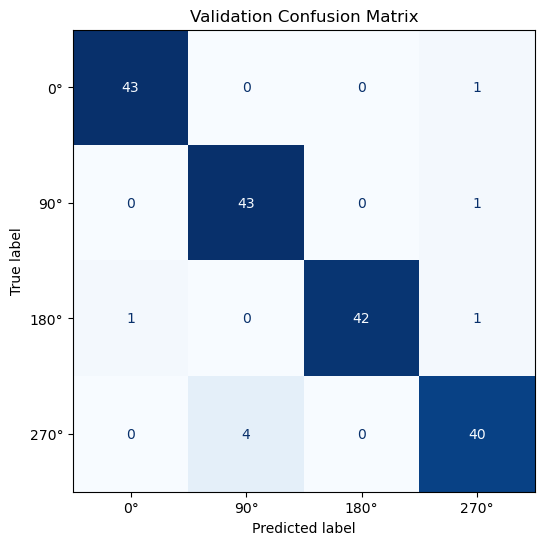

In [ ]:
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history['train_loss'], label='Train Loss')
ax1.plot(history['val_loss'], label='Val Loss')
ax1.axvline(STAGE1_EPOCHS - 0.5, color='gray', linestyle='--', label='Stage 2 Start')
ax1.set_title("Loss Curve")
ax1.set_xlabel("Epoch")
ax1.legend()

ax2.plot(history['train_acc'], label='Train Acc')
ax2.plot(history['val_acc'], label='Val Acc')
ax2.axvline(STAGE1_EPOCHS - 0.5, color='gray', linestyle='--', label='Stage 2 Start')
ax2.set_title("Accuracy Curve")
ax2.set_xlabel("Epoch")
ax2.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'training_curves_resnet18.png')
plt.show()

# Collect predictions for the entire validation set
all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for inputs, labels in val_loader:
        outputs = model(inputs.to(device))
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

print("\n--- Classification Report ---")
print(classification_report(all_labels, all_preds, target_names=[f"{c}°" for c in CLASS_NAMES]))

# Confusion Matrix display
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[f"{c}°" for c in CLASS_NAMES])
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title("Validation Confusion Matrix")
plt.savefig(OUTPUT_DIR / 'confusion_matrix_resnet18.png')
plt.show()

## 6. Export Final Exam Model Checkpoint

In [ ]:
# Export final model package with necessary metadata for evaluation scripts
checkpoint = {
    'model_architecture': 'resnet18',
    'model_state_dict': model.state_dict(),
    'num_classes': len(CLASS_NAMES),
    'class_names': CLASS_NAMES,
    'class_angles': CLASS_ANGLES,
    'rotation_convention': ROTATION_CONVENTION,
    'image_size': IMAGE_SIZE,
    'imagenet_mean': IMAGENET_MEAN,
    'imagenet_std': IMAGENET_STD,
    'val_accuracy': best_val_acc
}

torch.save(checkpoint, MODEL_SAVE_PATH)
print(f"Successfully saved exam model to: {MODEL_SAVE_PATH}")

Successfully saved exam model to: /Users/sam/ai_concepts/project/receipt_project_outputs/thai_receipt_orientation_resnet18.pth


In [11]:
checkpoint = torch.load(MODEL_SAVE_PATH, map_location=device)
model = create_model(len(CLASS_NAMES))
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)
model.eval()

/var/folders/99/2d6hh2xn6dv2s2vgy48lx3_00000gn/T/ipykernel_99450/152233662.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(MODEL_SAVE_PATH, map_l

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [12]:
val_loss, val_acc = eval_loop(model, val_loader, criterion)
print(f"Sanity check: {val_acc*100:.2f}%")

Sanity check: 95.45%


In [16]:

val_loss, val_acc = eval_loop(model, val_loader, criterion)
print(f"Sanity check — current model val accuracy: {val_acc*100:.2f}%")

import torch.nn.functional as F
import torchvision.transforms.functional as TF

class ExamExportWrapper(nn.Module):
    def __init__(self, base_model, image_size, mean, std):
        super().__init__()
        self.base_model = base_model
        self.register_buffer('image_size', torch.tensor(int(image_size)))
        self.register_buffer('mean', torch.tensor(mean, dtype=torch.float32).view(1, 3, 1, 1))
        self.register_buffer('std', torch.tensor(std, dtype=torch.float32).view(1, 3, 1, 1))

    def forward(self, x):
        # Input must already be resized to (image_size, image_size) via PIL before calling this.
        x = (x - self.mean) / self.std
        return self.base_model(x)


EXAM_MODEL_PATH = OUTPUT_DIR / 'thai_receipt_orientation_resnet18_EXAM.pth'

base_model_cpu = copy.deepcopy(model).cpu().eval()
exam_wrapper = ExamExportWrapper(base_model_cpu, IMAGE_SIZE, IMAGENET_MEAN, IMAGENET_STD).eval()

example_input = torch.rand(1, 3, IMAGE_SIZE, IMAGE_SIZE)
traced_exam_model = torch.jit.trace(exam_wrapper, example_input)
torch.jit.save(traced_exam_model, str(EXAM_MODEL_PATH))

print('Saved portable exam model:', EXAM_MODEL_PATH)
print('Size (MB):', round(EXAM_MODEL_PATH.stat().st_size / (1024 ** 2), 1))

Sanity check — current model val accuracy: 95.45%
Saved portable exam model: /Users/sam/ai_concepts/project/receipt_project_outputs/thai_receipt_orientation_resnet18_EXAM.pth
Size (MB): 42.8
